FIRST 10 RECORDS
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service       

C:\Users\HDC0422183\AppData\Local\Temp\ipykernel_12536\428928073.py:51: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


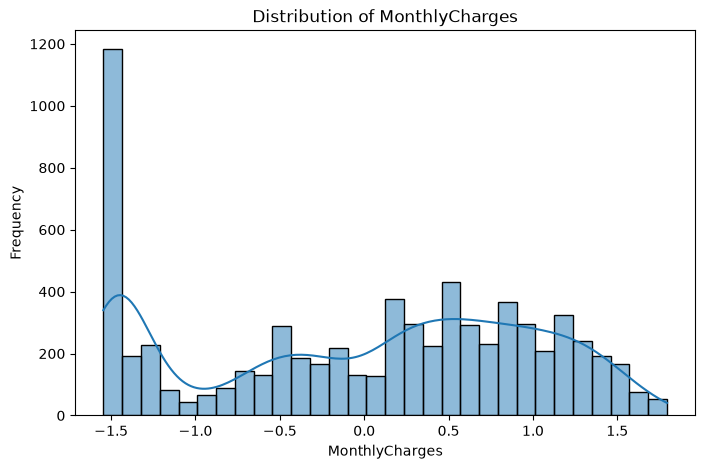

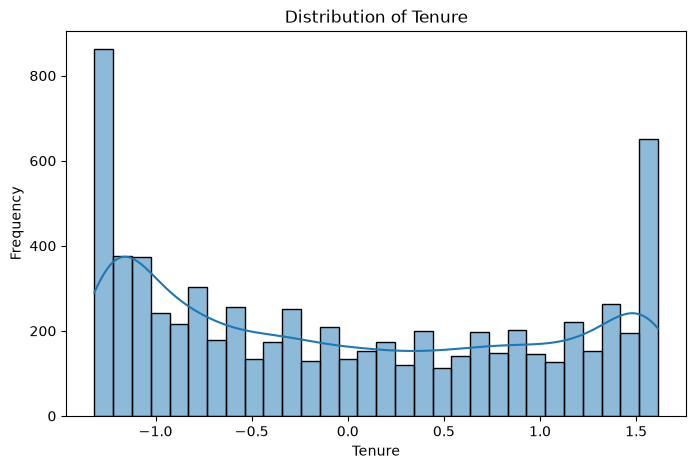

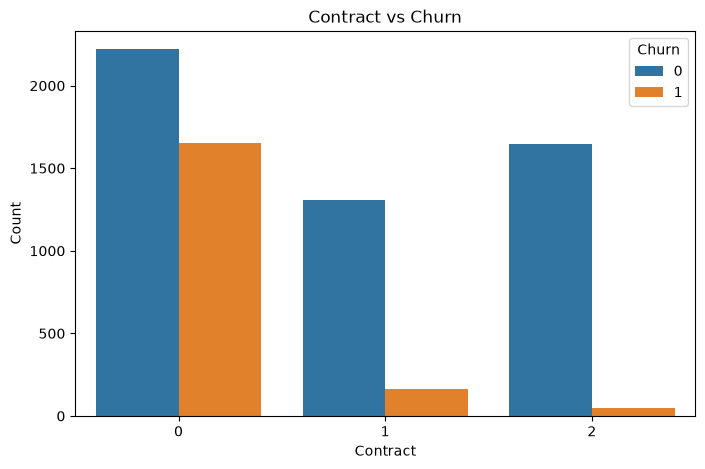

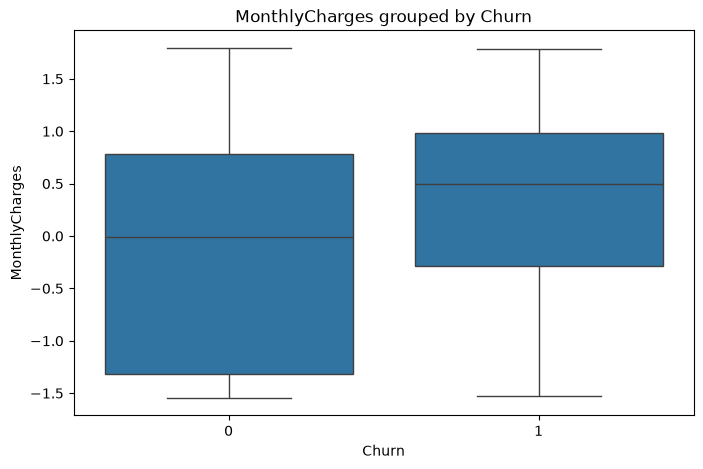

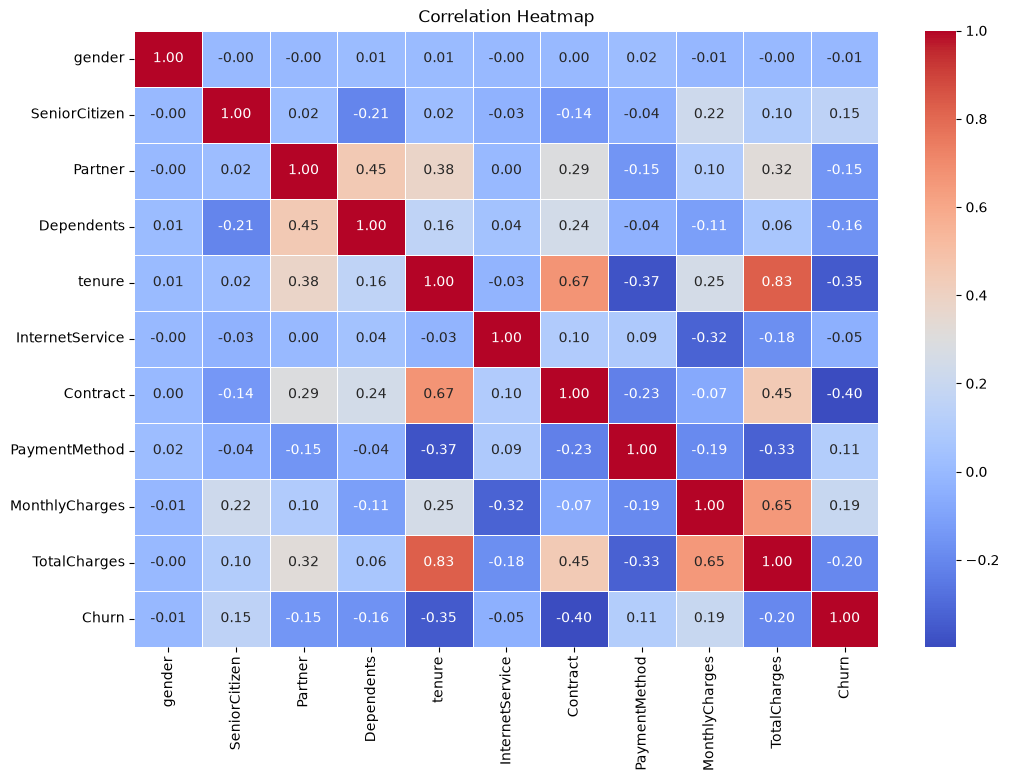

In [13]:
#Ex1: Data Preprocessing and Cleaning
#Problem Statement:
#A telecommunications company is experiencing customer churn (customers leaving the
#service). Before building a machine learning model to predict churn, the data science team must
#clean and preprocess the customer data to ensure high-quality input for analysis.
#You are a Data Scientist working for the company. Your task is to preprocess the customer
#dataset by handling missing values, removing inconsistencies, transforming categorical
#features, scaling numerical attributes, and visualizing important relationships.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv(r"C:\Users\HDC0422183\Downloads\archive (4)\TelcoCustomer-Churn.csv")

print("FIRST 10 RECORDS")
print(df.head(10))

print("\nLAST 10 RECORDS")
print(df.tail(10))

print("\nSHAPE OF DATASET")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATASET INFORMATION")
df.info()

print("\nSUMMARY STATISTICS")
print(df.describe(include="all"))

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE RECORDS")
print(df.duplicated().sum())

df = df.drop_duplicates()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

encode_cols = [
    "gender",
    "Partner",
    "Dependents",
    "Contract",
    "PaymentMethod",
    "InternetService",
    "Churn"
]

le = LabelEncoder()

for col in encode_cols:
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()

df[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.fit_transform(
    df[["tenure", "MonthlyCharges", "TotalCharges"]]
)

plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("MonthlyCharges grouped by Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()